In [70]:
import os
from typing import TypedDict, List, Dict, Any, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

In [71]:
from IPython.display import display, Image

In [72]:
#An State Object that we will pass around our nodes, the object is a dictionary
class State(TypedDict):
    # 

    """name: list[str]  # Contains firstname, lastname, middlename

    # The email being collected
    email: str

    # The phone numer being collected
    phone_no: int

    # what customer wants to do
    request: str"""

    user_input: str  #State has one key called user_input
    first_name: Optional[str]
    middle_name: Optional[str]
    last_name: Optional[str]
    email: Optional[str]

In [58]:
import sqlite3

#Connect to a database
connection = sqlite3.connect("Onboardingg.db")

# Create a cursor object to execute SQL commands
cursor = connection.cursor()

#Create a table (if it doesn't already exist)
cursor.execute(
    """
    CREATE TABLE IF NOT EXISTS profile (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        first_name TEXT,
        last_name TEXT,
        middle_name TEXT,
        phone_number INTEGER,
        email_address TEXT,
        customer_request TEXT
    )
"""
)

In [73]:
# Initialize our LLM

from dotenv import load_dotenv
load_dotenv()

model = ChatOpenAI(temperature=0)

def take_input(state):
    state["user_input"] = input("Hi there! I am Jeff, what can I do for you today?")
    return {"user_input": state["user_input"]} 

def get_name(state):
    state["user_input"] = input("Please provide your name in this order and format: Firstname Middlename, Lastname. Thanks! ")
    first_name, middle_name, last_name = (state["user_input"]).split()
    state["first_name"] = first_name
    state["middle_name"] = middle_name
    state["last_name"] = last_name
    print(f"confirm your name is: \n firstname :{first_name} \n middlename :{middle_name} \n lastname :{last_name}")
    return{"user_input": state["user_input"], "first_name": state["first_name"], "last_name": state["last_name"], "middle_name": state["middle_name"]}

def welcome(state):
    prompt = f""" You are acting as an onboarding agent. You will welcome the customer by saying:
               Hi there! I am Jeff, Trust you are good! Firstly, let me get your details whats your name, provide it in this order and format: Firstname Middlename Lastname."""
    print("\n")
    print("Hi there! I am Jeff, Trust you are good! Firstly, let me get your details whats your name, provide it in this order: First name Last name Middle name. Thanks!")

#def split_name(state):
    #first_name, middle_name, last_name = (state["user_input"]).split()
    #state["first_name"] = first_name
    #state["middle_name"] = middle_name
    #state["last_name"] = last_name
    #print(f"confirm your name is: {first_name}, {last_name}, {middle_name}")
    #return{"user_input": state["user_input"], "first_name": state["first_name"], "last_name": state["last_name"], "middle_name": state["middle_name"]}

#def confirmation(state):
    #confirm = input("Please confirm your details are correct (yes/no): ")
    #if confirm.lower() == yes:
        #return
    #if confirm.lower() == no:


def get_email(state):
    email =input("Please provide your email address: ")
    state["email"] = email
    print(f"confirm your email is: {email}")
    return {"email": state["email"]}

def get_phone_number(state):
    phone_number = input("Please provide your phone number: ")
    state["phone_number"] = phone_number
    print(f"confirm your phone number is: {phone_number}")
    return {"phone_number": state["phone_number"]}

def get_customer_request(state):
    request = input("Please provide your request: ")
    state["request"] = request
    print(f"confirm your request is: {request}")
    return {"request": state["request"]}


def execute_query(query, params=()):
    with sqlite3.connect("Onboardingg.db") as conn:
        cursor = conn.cursor()
        cursor.execute(query, params)
        conn.commit()



def insert_profile_to_db(state):
    query = f"INSERT INTO profile (first_name, middle_name, last_name, email_address, phone_number, customer_request) VALUES (?, ?, ?, ?, ?, ?)"
    params = (state.get("first_name"), state.get("middle_name"), state.get("last_name"), state.get("email"), state.get("phone_number"), state.get("request"))
    print(query)
    execute_query(query, params)
    return state




In [ ]:
def

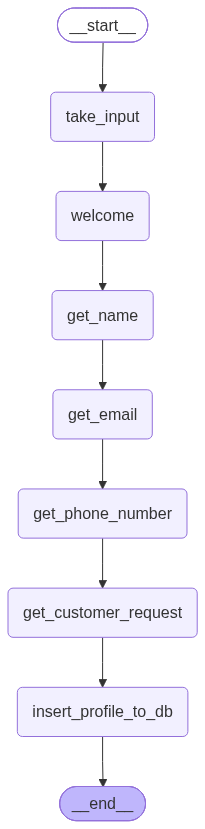

In [75]:
onboard_graph = StateGraph(State)

# Start the edges
onboard_graph.add_node("take_input", take_input)
onboard_graph.add_node("welcome", welcome)
onboard_graph.add_node("get_name", get_name)
onboard_graph.add_node("get_email", get_email)
onboard_graph.add_node("get_phone_number", get_phone_number)
onboard_graph.add_node("get_customer_request", get_customer_request)
#onboard_graph.add_node("execute_query", execute_query)
onboard_graph.add_node("insert_profile_to_db", insert_profile_to_db)


onboard_graph.add_edge(START, "take_input")
onboard_graph.add_edge("take_input", "welcome")
onboard_graph.add_edge("welcome", "get_name")
onboard_graph.add_edge("get_name", "get_email")
onboard_graph.add_edge("get_email", "get_phone_number")
onboard_graph.add_edge("get_phone_number", "get_customer_request")
#onboard_graph.add_edge("get_customer_request", "execute_query")
#onboard_graph.add_edge("execute_query", "insert_profile_to_db")
onboard_graph.add_edge("get_customer_request", "insert_profile_to_db")
onboard_graph.add_edge("insert_profile_to_db", END)
compiled_graph = onboard_graph.compile()

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [78]:
customer_input = "Hi there"
result = compiled_graph.invoke({"user_input":customer_input})



Hi there! I am Jeff, Trust you are good! Firstly, let me get your details whats your name, provide it in this order: First name Last name Middle name. Thanks!


ValueError: not enough values to unpack (expected 3, got 0)

In [ ]:

""""
def get_name(state: OnboardState):
      prompt = f"""You are acting as an onboarding agent. You will onboard new users by getting their names. Ask them to provide their name in this order and format: First name Last name Middle name."""


def write_to_database():
    cursor.execute(
    "INSERT INTO profile (first_name) VALUES (?)", 
    (user_input[0].lstrip())"""

In [8]:
n = "O'meara Lawal Michael"

In [13]:
first, second, third  = n.split()
print(first, "/", second, third)

O'meara / Lawal Michael
